<h1 align="center" style="font-weight: bold;">Bicycle Rental Demand Prediction</h1>

### **Business Problem Understanding**

Capital Bikeshare is a modern bicycle rental company that operates an integrated automated system covering membership registration, bike rental, and bike return processes. Users can rent bicycles from one particular position and return them at another position seamlessly.

Currently, the company operates **more than 8,000 bicycles across over 800 stations**, which creates a complex operational challenge. Without accurate demand prediction, the company may experience problems:

1. Bike shortages at high-demand periods, which will lead to users' dissatisfaction, loss of customers, and ultimately revenue decline; or
2. Excess idle bikes during low-demand periods, leading to inefficiencies in areas with a high concentration of bicycles, wasted maintenance costs, and ultimately financial losses.

To overcome these issues, the company seeks to forecast bike demand accurately and guide smarter operational decisions.

### **Objectives**

- Predict future pattern bike rental demand to support inventory and station management.  
- Improve bike availability and reduce unmet demand.  
- Optimize redistribution and maintenance planning.  
- Support data-driven decision making for expansion and operational strategies.  


### **Analytical Approach**

The model development process will involve the following key steps:

- Perform **exploratory data analysis (EDA)** to identify key factors influencing bike demand (e.g., weather, seasonality, time).  
- Conduct **feature engineering** to enhance predictive power.  
- Develop and evaluate **regression-based predictive models** to estimate daily bike rental demand.  
- Validate the model using appropriate performance metrics (e.g., RMSE, MAE, R²) and select the best-performing model.

### **Evaluation Metrics**

To evaluate the performance of the bike rental demand prediction model several evaluation metrics are used to assess accuracy, stability, and business relevance.

**1. Mean Absolute Error (MAE)**

MAE measures the average absolute difference between the actual and predicted bike rental demand.

MAE = $\frac{1}{n} \sum_{i=1}^{n} | y_i - \hat{y_i} |$

**Interpretation:**  
- MAE represents the average magnitude of prediction errors in the same unit as bike demand (number of rentals).  
- **Lower MAE indicates better model accuracy.**

---

**2. Mean Absolute Percentage Error (MAPE)**

MAPE measures the average prediction error in percentage relative to the actual bike demand values.

MAPE = $\frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y_i}}{y_i} \right| \times 100\%$

**Interpretation:**  
- MAPE shows the relative error scale of the model predictions.  
- It is suitable when bike demand varies significantly across time periods, as it expresses error in percentage form.  
- **Lower MAPE indicates higher predictive accuracy.**

---

**3. Root Mean Square Error (RMSE)**

RMSE measures the square root of the average squared differences between actual and predicted bike rental demand.

RMSE = $\sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$

**Interpretation:**
- RMSE represents the average magnitude of prediction errors in the same unit as bike demand (number of rentals), but with greater sensitivity to large errors.
- A lower RMSE value indicates that the model is able to capture demand fluctuations more accurately.  
- **Lower RMSE indicates better model accuracy, especially in capturing outlier events.**

---

**4. R-squared (R²)**

R² measures how well the model explains the variability in bike rental demand.

R² = $1 - \frac{\sum (y_i - \hat{y_i})^2}{\sum (y_i - \bar{y})^2}$

**Interpretation:**  
- R² ranges from **0 to 1**, where values closer to **1** indicate that the model does a good job capturing how bike demand changes in response to the predictors.
- Values close to **0** indicate that the model doesn’t explain much of the variability, which could be because the data is noisy or some factors are missing—but it doesn’t automatically make the model useless.


With this combination of metrics, the company can assess how effectively the model predicts bicycle rental demand, enabling more informed bike availability management.

### **Data Understanding**

Feature Information:


| Column               | Definition                                              |
| -------------------- | ------------------------------------------------------- |
| Date                 | Observation date (YYYY-MM-DD).                          |
| Humidity             | Relative humidity, normalized to the range [0, 1].      |
| Weather Situation    | Weather situation category (1, 2, 3, 4).                |
| Holiday              | Holiday indicator (1 = holiday, 0 = not holiday).       |
| Season               | Season category (1, 2, 3, 4).                           |
| Apparent Temperature | Apparent (feels-like) temperature, normalized.          |
| Temperature          | Actual air temperature, normalized to the range [0, 1]. |
| Hour                 | Hour of the day (0–23).                                 |
| Casual               | Number of casual (unregistered) users.                  |
| Registered           | Number of registered users.                             |
| Count of Bike Rental | Total number of bike rentals (casual + registered).     |


`weathersit`:

- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog


`holiday`:

- 1: holiday
- 0: non-holiday


`season`:

- 1: Spring 
- 2: Summer
- 3: Fall
- 4: Winter




### Import Libraries

In [1]:
# analysis
import numpy as np
import pandas as pd
import random
import math
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFromModel
import time

# data preprocessing
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, OrdinalEncoder, PolynomialFeatures
)

# imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer, KNNImputer

# pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# data splitting
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate,
    GridSearchCV, RandomizedSearchCV, KFold
)

# machine learning model
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
    AdaBoostRegressor
)
from lightgbm import LGBMRegressor

# evaluation metrics
from sklearn.metrics import (
   make_scorer, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
)

# feature selection
from sklearn.feature_selection import (
    SelectKBest, f_regression, mutual_info_regression, RFE
)


import warnings
import pickle
import shap
from datetime import datetime
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth',None)

### Import Data

In [2]:
bike=pd.read_csv('data_bike_sharing.csv', parse_dates=['dteday'])
bike

,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
0,2011-12-09,0.62,1,0,4,0.3485,0.36,16,24,226,250
1,2012-06-17,0.64,1,0,2,0.5152,0.54,4,2,16,18
2,2011-06-15,0.53,1,0,2,0.6212,0.62,23,17,90,107
3,2012-03-31,0.87,2,0,2,0.3485,0.36,8,19,126,145
4,2012-07-31,0.55,1,0,3,0.6970,0.76,18,99,758,857
...,...,...,...,...,...,...,...,...,...,...,...
12160,2012-01-25,0.75,1,0,1,0.2273,0.24,7,14,243,257
12161,2012-07-06,0.62,1,0,3,0.7424,0.78,0,39,63,102
12162,2012-02-20,0.60,2,1,1,0.2121,0.24,5,0,6,6
12163,2012-03-31,0.77,2,0,2,0.4242,0.42,2,14,55,69


In [3]:
# agg = bike.groupby('dteday')['hr'].value_counts().reset_index(name='count')

# display(agg[agg['dteday'] == '2011-01-01'],agg[agg['dteday'] == '2011-01-02'])

In [4]:
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      12165 non-null  datetime64[ns]
 1   hum         12165 non-null  float64       
 2   weathersit  12165 non-null  int64         
 3   holiday     12165 non-null  int64         
 4   season      12165 non-null  int64         
 5   atemp       12165 non-null  float64       
 6   temp        12165 non-null  float64       
 7   hr          12165 non-null  int64         
 8   casual      12165 non-null  int64         
 9   registered  12165 non-null  int64         
 10  cnt         12165 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(7)
memory usage: 1.0 MB


**Checking Missing Values**

In [5]:
missing = pd.DataFrame(round(bike.isna().sum()*100/len(bike),1)).reset_index()
missing.rename(columns={'index':'column', 0:'missing percentage'},inplace=True)
missing['missing percentage'] = (missing['missing percentage'].astype(str)+'%')
missing

,column,missing percentage
0,dteday,0.0%
1,hum,0.0%
2,weathersit,0.0%
3,holiday,0.0%
4,season,0.0%
5,atemp,0.0%
6,temp,0.0%
7,hr,0.0%
8,casual,0.0%
9,registered,0.0%


### **1. Exploratory Data Analysis**

Our response variable in this model is the *total number of bike rentals*, represented by the `cnt` column. The first step in our data exploration is to examine the distribution of `cnt`, which helps us understand the variability, detect potential outliers, and inform appropriate modeling choices.

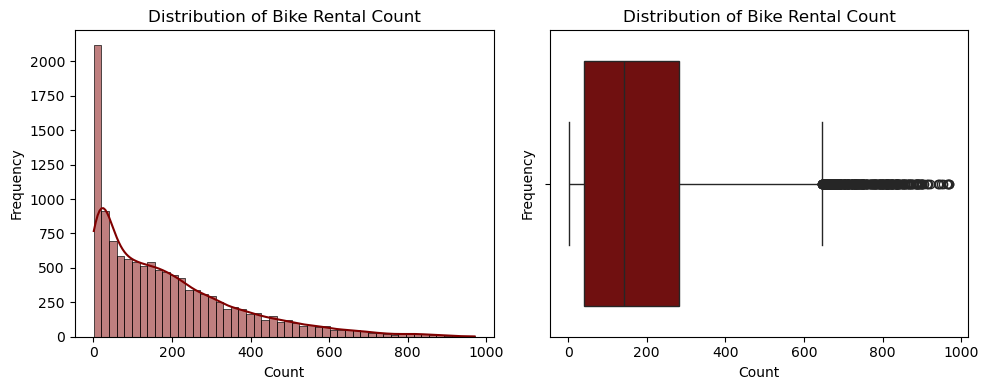

In [6]:
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
sns.histplot(data=bike, x='cnt', bins=50, kde=True,color='maroon')
plt.title('Distribution of Bike Rental Count')
plt.xlabel('Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(data=bike,x='cnt',color='maroon')
plt.title('Distribution of Bike Rental Count')
plt.xlabel('Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [7]:
Q1 = bike['cnt'].quantile(0.25)
Q3 = bike['cnt'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 : {Q1}.")
print(f"Q2 : {bike['cnt'].median()}.")
print(f"Q3 : {Q3}.")
print(f"IQR: {IQR}.")
print(f"Lower Outlier : {lower_bound} -> 0.")
print(f"Upper Outlier : {upper_bound}.")

Q1 : 40.0.
Q2 : 142.0.
Q3 : 282.0.
IQR: 242.0.
Lower Outlier : -323.0 -> 0.
Upper Outlier : 645.0.


Based on the plots above, `cnt` exhibits a right-skewed distribution with a considerable number of high-end outliers with upperbound= 645 and median= 142. This pattern is expected, as bike rental demand is influenced by multiple factors, including holidays, seasonal variations, and peak usage hours. The skewness and outliers are important to note, as they may affect model performance and inform decisions on transformations or choice of algorithms. Further analysis will be conducted in the following section.

**Bike Rental Demand by Seasonal Conditions**

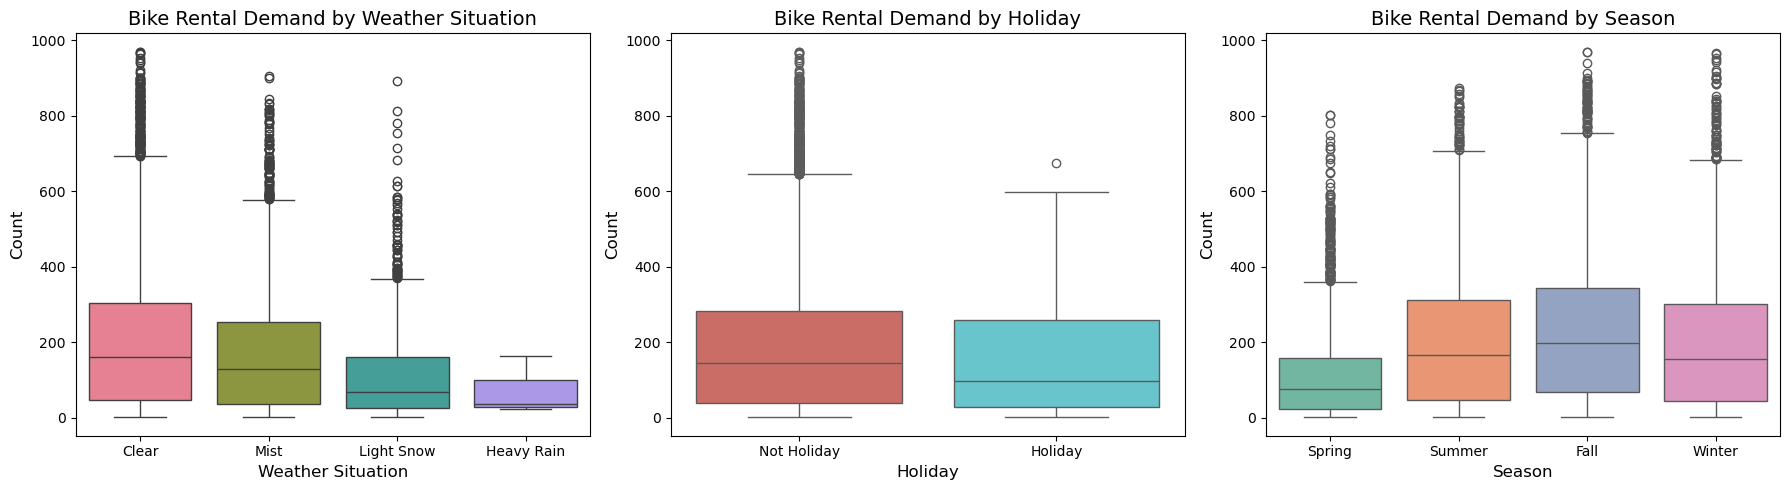

In [8]:
plt.figure(figsize=(18,5))

plt.subplot(1, 3, 1)
sns.boxplot(data=bike, x='weathersit', y='cnt',palette='husl')
plt.title('Bike Rental Demand by Weather Situation', fontsize=14)
plt.xlabel('Weather Situation', fontsize=12)
plt.xticks([0, 1, 2, 3], ['Clear', 'Mist', 'Light Snow', 'Heavy Rain'], fontsize=10)
plt.ylabel('Count', fontsize=12)

plt.subplot(1, 3, 2)
sns.boxplot(data=bike, x='holiday', y='cnt',palette='hls')
plt.title('Bike Rental Demand by Holiday', fontsize=14)
plt.xlabel('Holiday', fontsize=12)
plt.xticks([0, 1], ['Not Holiday', 'Holiday'], fontsize=10)
plt.ylabel('Count', fontsize=12)

plt.subplot(1, 3, 3)
sns.boxplot(data=bike, x='season', y='cnt',palette='Set2')
plt.title('Bike Rental Demand by Season', fontsize=14)
plt.xlabel('Season', fontsize=12)
plt.xticks([0, 1, 2, 3], ['Spring', 'Summer', 'Fall', 'Winter'], fontsize=10)
plt.ylabel('Count', fontsize=12)



plt.tight_layout()
plt.show()

Boxplots show variations of bike demand on various seasonal condition.

A. Rental demand decreases as weather conditions worsen:

- Clear
  - Highest median rental count.
  - Wide variability (large IQR).
  - Many high-demand outliers.

- Mist
  - Slightly lower median than clear weather.
  - Moderate spread.
  - Still relatively strong demand.

- Light Snow
  - Noticeably lower median.
  - Fewer extreme high-demand days.
  - Demand becomes more suppressed.

- Heavy Rain
  - Lowest median rental count.
  - Tight distribution (low variability).
  - Rare high-demand outliers.

Conclusion: Weather has a strong negative relationship with bike rentals. Clear conditions maximize demand, while heavy rain significantly reduces it.

B. Rentals tend to be higher on non-holidays:

- Not Holiday
  - Higher median rental count.
  - Greater variability.
  - More high-demand outliers.

- Holiday
  - Slightly lower median.
  - Narrower distribution.

Conclusion: This suggesting demand is primarily driven by commuting rather than leisure.

C. Rental demand peaks in Fall:

- Fall
  - Highest median rental count.
  - Many high-demand outliers.
  - Peak rental season.

- Summer
  - Second-highest median.
  - High variability.

- Winter
  - Moderate demand.
  - Slightly lower than summer.

- Spring
  - Lowest median among seasons.
  - More low-demand days.


Overall Insights:

- Weather has the strongest impact on daily bike rentals.
- Seasonality significantly affects demand, with Fall being optimal.
- Holidays slightly reduce rentals, indicating commuter-driven usage patterns.
- Numerous outliers suggest occasional surge days (exceptional weather or special events).




**Hourly and Daily Trend of Bike Demand**


In [9]:
# verifying if the `dteday` column contains all dates for each month (from 1st to 28/29/30/31).
full_dates = pd.date_range(bike['dteday'].min(), bike['dteday'].max())
missing_dates = pd.DataFrame(full_dates.difference(bike['dteday']))

print(missing_dates)

Empty DataFrame
Columns: [0]
Index: []


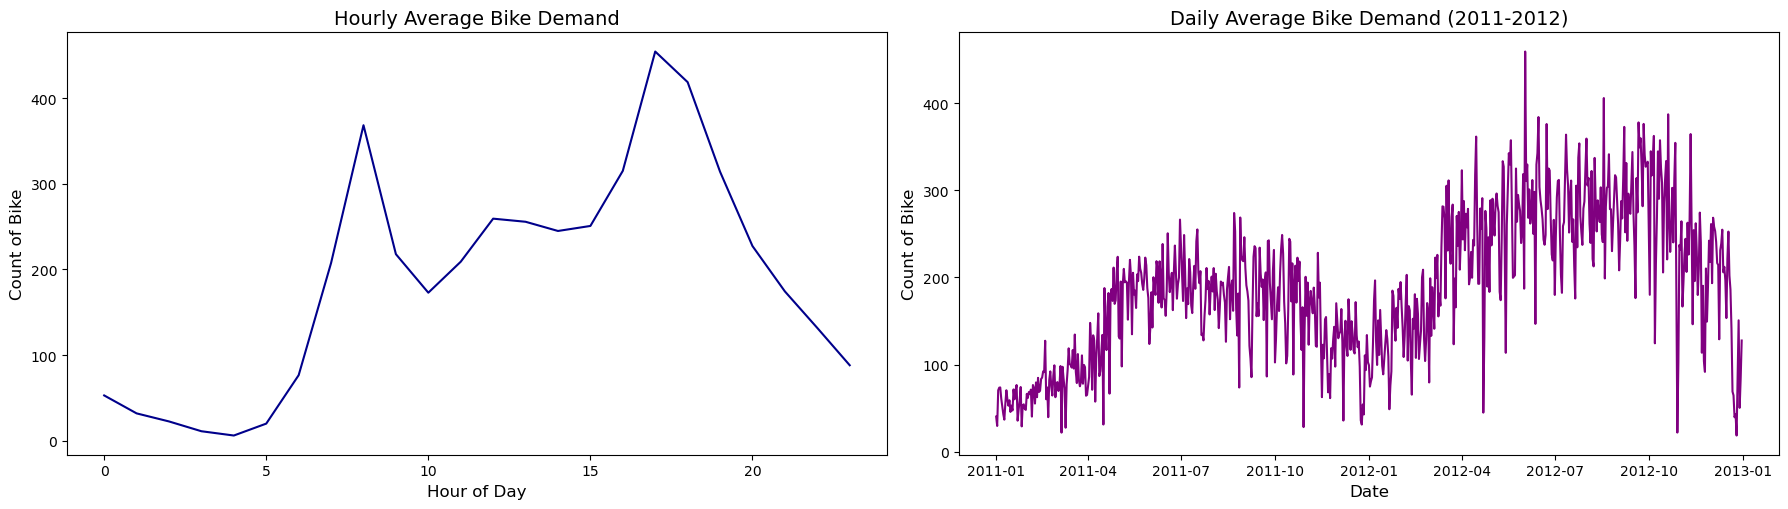

In [10]:
plt.figure(figsize=(18,5.2))

plt.subplot(1, 2, 1)
sns.lineplot(data=bike.groupby('hr')['cnt'].mean().reset_index(), x='hr', y='cnt',color='DarkBlue')
plt.title('Hourly Average Bike Demand', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Count of Bike', fontsize=12)

plt.subplot(1, 2, 2)
sns.lineplot(data=bike.groupby('dteday')['cnt'].mean().reset_index(), x='dteday', y='cnt',color='purple')
plt.title('Daily Average Bike Demand (2011-2012)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Count of Bike', fontsize=12)

plt.tight_layout()
plt.show()

The lineplots reveal a broadly similar structural pattern in both *Hourly Average Bike Demand* and *Daily Average Bike Demand*. The hourly demand shows a clear bimodal pattern, with a prominent peak around 8 a.m., corresponding to the morning commuting rush hour. Demand then declines during midday before rising again in the late afternoon and early evening, reflecting the return-home commuter flow.

Similarly, the daily demand pattern throughout the year exhibits a structured fluctuation. Demand increases toward the middle of the year, likely associated with more favorable weather conditions, before gradually declining as winter approaches. A noticeable rise also appears in late summer, which may be linked to the resumption of regular work and school routines.Additionally, overall demand in 2012 appears consistently higher than in 2011, suggesting system growth, increased user adoption, or broader expansion of bike-sharing usage over time.

Conclusion:

The similarity in these patterns likely reflects the influence of consistent human commuting routines combined with seasonal weather variations. Furthermore, the higher demand observed in 2012 indicates a possible upward trend in overall system utilization.

**Distribution of Temperature and Its Correlation with Bike Rental Demand**

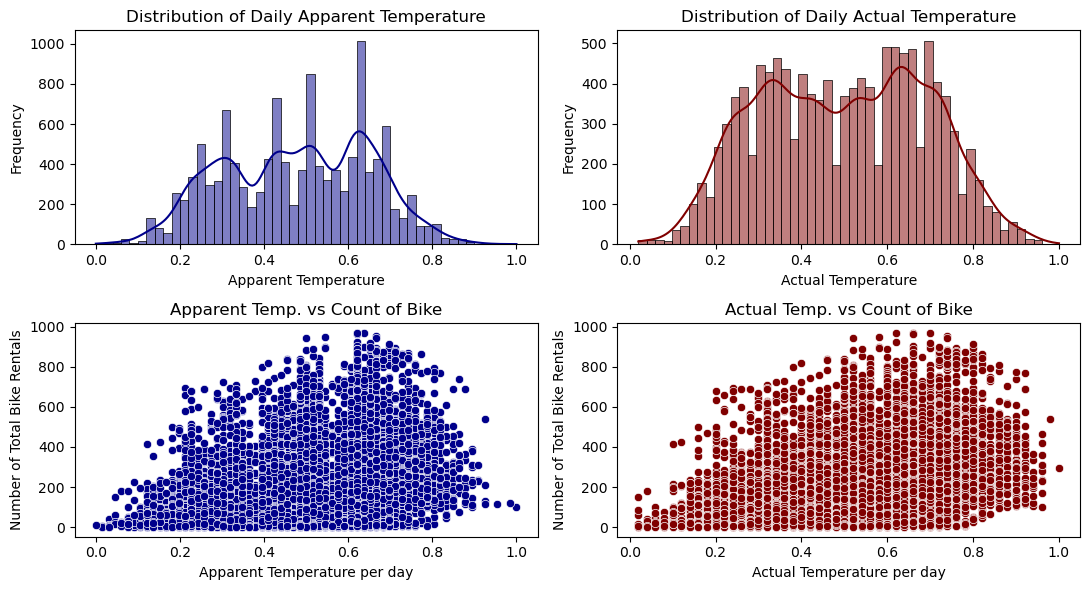

In [11]:
plt.figure(figsize=(11,6))

plt.subplot(2, 2, 1)
sns.histplot(data=bike, x='atemp', bins=50, kde=True, color='DarkBlue')
plt.title('Distribution of Daily Apparent Temperature')
plt.xlabel('Apparent Temperature')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.histplot(data=bike, x='temp', bins=50, kde=True, color='maroon')
plt.title('Distribution of Daily Actual Temperature')
plt.xlabel('Actual Temperature')
plt.ylabel('Frequency')


plt.subplot(2, 2, 3)
sns.scatterplot(data=bike, x='atemp', y='cnt',color='DarkBlue')
plt.title('Apparent Temp. vs Count of Bike')
plt.xlabel('Apparent Temperature per day')
plt.ylabel('Number of Total Bike Rentals')

plt.subplot(2, 2, 4)
sns.scatterplot(data=bike, x='temp', y='cnt',color='maroon')
plt.title('Actual Temp. vs Count of Bike')
plt.xlabel('Actual Temperature per day')
plt.ylabel('Number of Total Bike Rentals')


plt.tight_layout()
plt.show()

The histograms show that both apparent temperature and actual temperature are mostly concentrated in the mid-range, with fewer extremely low or extremely high values. This suggests that most recorded days fall within moderate weather conditions. The distribution of apparent temperature closely follows that of actual temperature, indicating that perceived temperature generally aligns well with the measured temperature.

The scatterplots clearly show a positive relationship between temperature and bike rental demand. As temperatures increase from colder to more comfortable levels, the number of bike rentals also rises noticeably. Demand tends to be highest during moderate to warm temperatures, while very cold days consistently show low rental counts. However, when temperatures become extremely high, the increase in demand does not appear as strong, suggesting that excessively hot weather may slightly discourage bike usage.

Overall, both actual and apparent temperatures have a strong influence on bike rental demand, highlighting how weather comfort plays an important role in shaping bike rental demand patterns.

**Distribution of Users and Its Correlation with Bike Rental Demand**

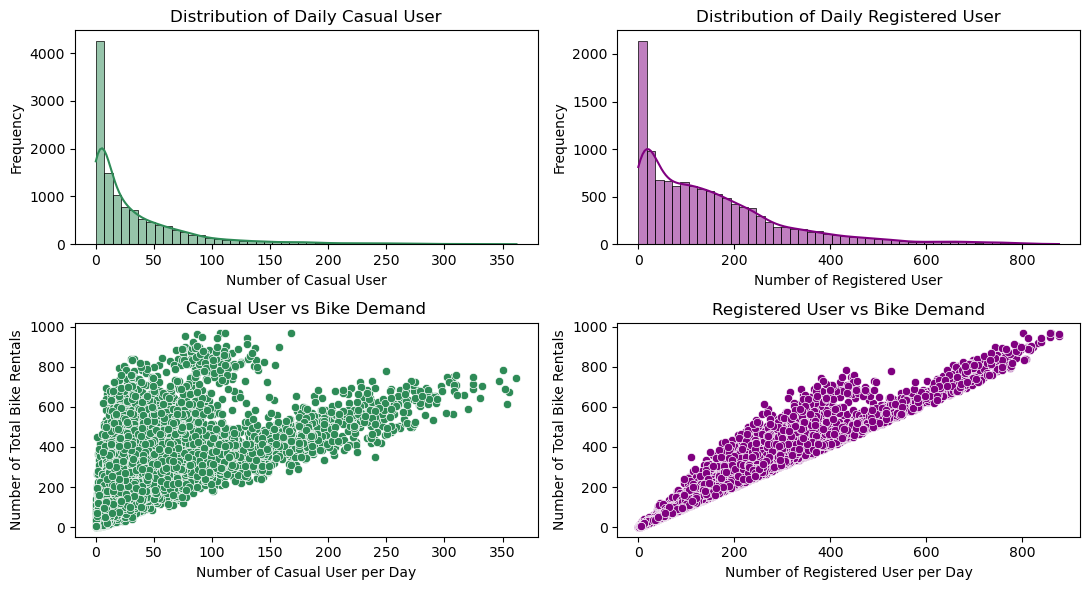

In [12]:
plt.figure(figsize=(11,6))

plt.subplot(2, 2, 1)
sns.histplot(data=bike, x='casual', bins=50, kde=True, color='seagreen')
plt.title('Distribution of Daily Casual User')
plt.xlabel('Number of Casual User')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.histplot(data=bike, x='registered', bins=50, kde=True, color='purple')
plt.title('Distribution of Daily Registered User')
plt.xlabel('Number of Registered User')
plt.ylabel('Frequency')


plt.subplot(2, 2, 3)
sns.scatterplot(data=bike, x='casual', y='cnt',color='seagreen')
plt.title('Casual User vs Bike Demand')
plt.xlabel('Number of Casual User per Day')
plt.ylabel('Number of Total Bike Rentals')

plt.subplot(2, 2, 4)
sns.scatterplot(data=bike, x='registered', y='cnt',color='purple')
plt.title('Registered User vs Bike Demand')
plt.xlabel('Number of Registered User per Day')
plt.ylabel('Number of Total Bike Rentals')

plt.tight_layout()
plt.show()

The four visualizations provide insights into the distribution of casual and registered users and their relationship with total bike demand. The histograms show that both casual and registered users have positively skewed distributions, meaning most days have relatively low user counts, with fewer days showing very high numbers. 

However, registered users tend to have higher daily counts and a wider spread compared to casual users, indicating more consistent and frequent usage. The scatter plots reveal a positive correlation between both user types and total bike rentals. As the number of casual or registered users increases, total bike demand also tends to increase. 

The relationship appears stronger for registered users, as the points are more tightly clustered around an upward trend, suggesting that registered users contribute more consistently to overall demand. In contrast, the casual user scatter plot shows more variability, possibly influenced by weather, weekends, or holidays. 

Overall, registered users are the primary drivers of daily bike demand, while casual users add variability and may represent opportunistic or recreational usage.

**Correlation of Each Numerical Variables**

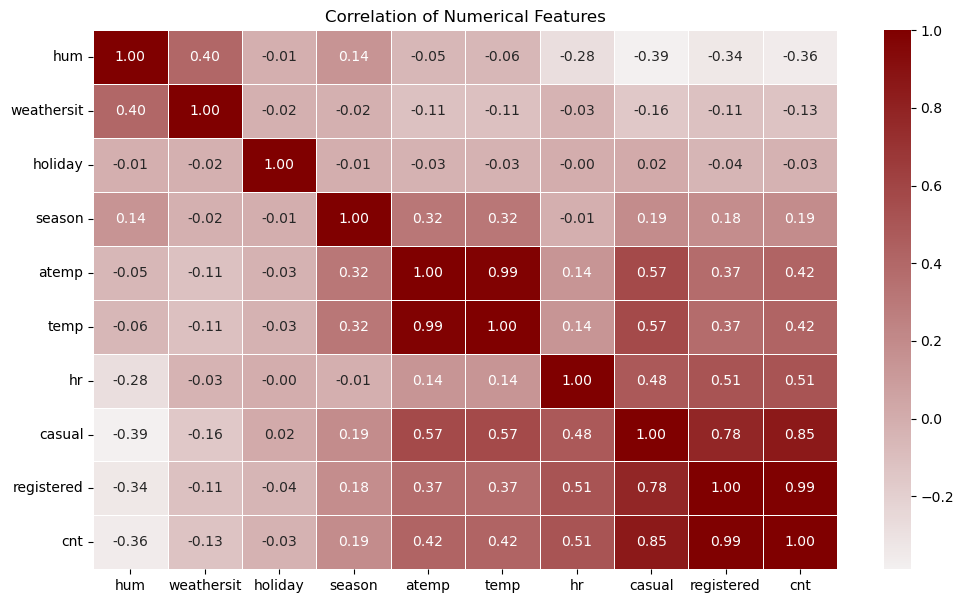

In [13]:
num = bike.select_dtypes(include='number')
plt.figure(figsize=(12,7))
sns.heatmap(num.corr(method='spearman'),annot=True, cmap=sns.light_palette('maroon', as_cmap=True), fmt='.2f', linewidths=0.5)
plt.title('Correlation of Numerical Features')
plt.show()

In this analysis, we categorize correlation coefficients into four levels:

1. < 0.2 : Very Weak

2. 0.2 – 0.4 : Weak

3. 0.4 – 0.7 : Moderate

4. \> 0.7 : Strong

Based on the heatmap, several variable pairs exhibit strong correlations, particularly casual–registered and atemp–temp. Identifying these strong relationships is important to prevent multicollinearity in the model.

Since the target variable (cnt) represents the total number of bike rentals and is calculated as the sum of casual and registered, including both variables as predictors would introduce redundancy. Therefore, these columns should not be used together as features. Similarly, temp and atemp are highly correlated, meaning that including both could also lead to multicollinearity. One of them should be removed during feature selection. This issue will be addressed further in the Feature Engineering section.one. We will hadle this in Feature Engineering in the following section.

 

### **2. Feature Engineering**

**Extracting `dteday`**

Since `dteday` is stored as a datetime variable, it cannot be directly used as a numerical feature in modeling. To generate more meaningful and usable features, we will extract it into several new variables: `year`, `month`, and `day_of_week`, all represented in numeric format as follows:

In [14]:
# Ekstrak fitur2 penting
bike['year'] = bike['dteday'].dt.year
bike['month'] = bike['dteday'].dt.month
bike['day_of_week'] = bike['dteday'].dt.dayofweek  # 0=Monday, 6=Sunday

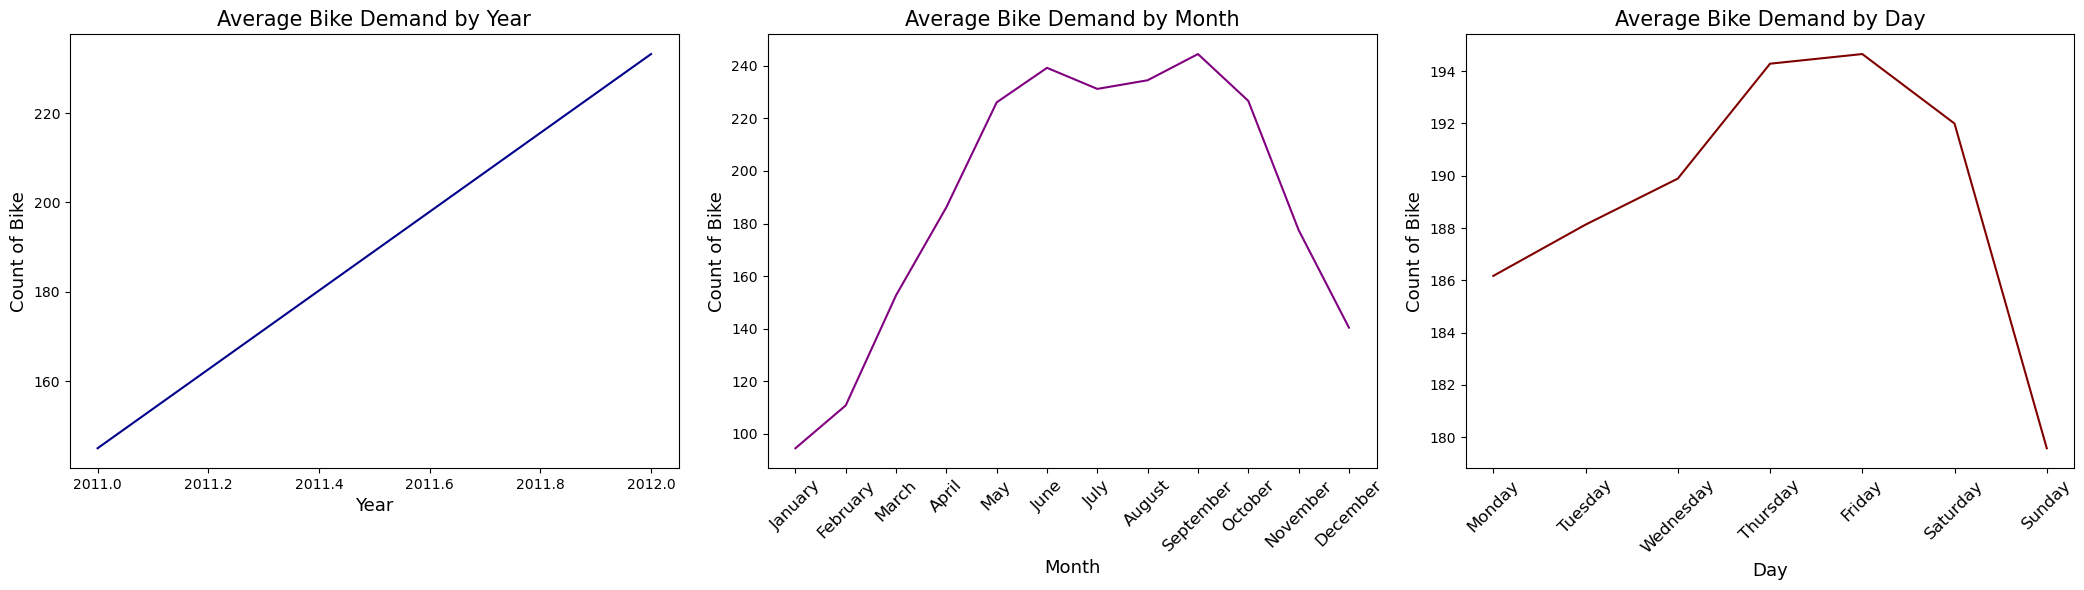

In [15]:
plt.figure(figsize=(21,6))

plt.subplot(1, 3, 1)
sns.lineplot(data=bike.groupby('year')['cnt'].mean().reset_index(), x='year', y='cnt',color='DarkBlue')
plt.title('Average Bike Demand by Year', fontsize=15)
plt.xlabel('Year', fontsize=13)
plt.ylabel('Count of Bike', fontsize=13)

plt.subplot(1, 3, 2)
sns.lineplot(data=bike.groupby('month')['cnt'].mean().reset_index(), x='month', y='cnt',color='purple')
plt.title('Average Bike Demand by Month', fontsize=15)
plt.xlabel('Month', fontsize=13)
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 
           ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'],
            rotation=45, fontsize=12)
plt.ylabel('Count of Bike', fontsize=13)

plt.subplot(1, 3, 3)
sns.lineplot(data=bike.groupby('day_of_week')['cnt'].mean().reset_index(), x='day_of_week', y='cnt',color='maroon')
plt.title('Average Bike Demand by Day', fontsize=15)
plt.xlabel('Day', fontsize=13)
plt.xticks([0, 1, 2, 3, 4, 5, 6],
           ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
            rotation=45, fontsize=12)
plt.ylabel('Count of Bike', fontsize=13)

plt.tight_layout()
plt.show()

Based on the new variables, we observe a clear increase in average bike demand from 2011 to 2012, suggesting that the bike-sharing service is growing in popularity.

Looking at the monthly pattern, demand rises steadily from winter into late spring and summer, peaking around June to September, and then gradually declines toward the colder months—this strongly hints at the impact of weather and seasonal activity. This confirms the pattern we saw on *Daily Average Bike Demand* througout 2011-2012.

Finally, the daily trend shows that demand is highest on weekdays, especially Thursday and Friday, and drops noticeably on Sunday. This suggests that many people rely on bikes for commuting during the workweek, while weekend usage is a bit lighter. Overall, bike demand appears to be influenced by long-term growth, seasonal weather patterns, and weekly commuting habits.

**Rechecking Corrrelation Between Features**

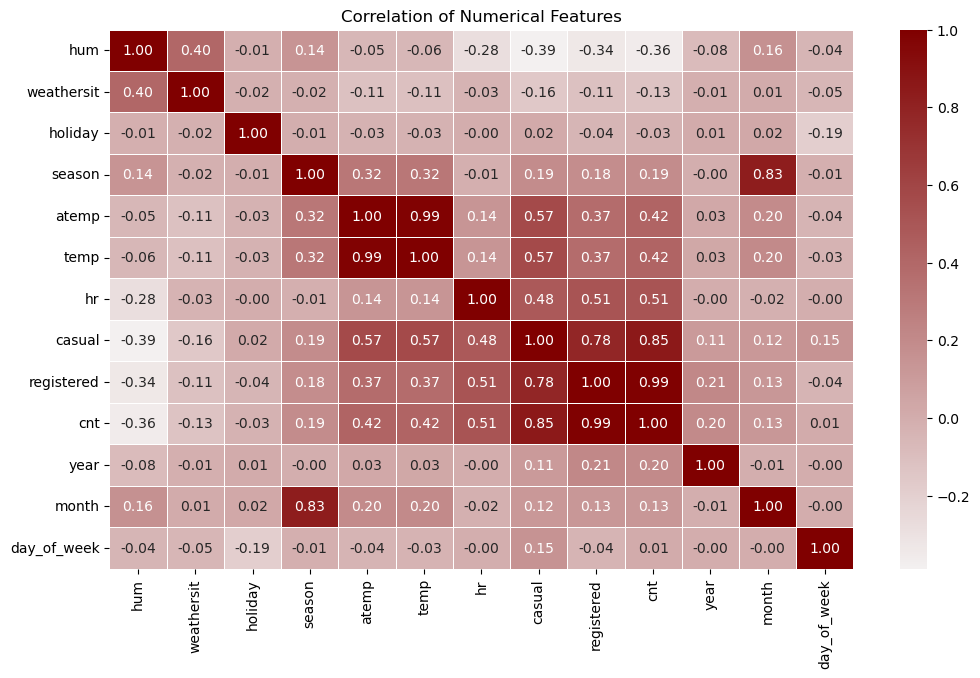

In [16]:
num = bike.select_dtypes(include='number')
plt.figure(figsize=(12,7))
sns.heatmap(num.corr(method='spearman'),annot=True, cmap=sns.light_palette('maroon', as_cmap=True), fmt='.2f', linewidths=0.5)
plt.title('Correlation of Numerical Features')
plt.show()

From the previous heatmap, we observed that `casual` and `registered`, as well as `atemp` and `temp`, exhibit very high correlations. To prevent multicollinearity and potential data leakage, we will remove `casual`, `registered`, and `atemp`. We will also remove `year` to build a better model prediction. Additionally, `season` and `month` are strongly correlated, so we will drop `month` to reduce redundancy in the model.

In [17]:
bike_clean=bike[['day_of_week',
       'hum', 'weathersit', 'holiday', 'season','temp',
       'hr', 'cnt']]

In [18]:
display(bike_clean.head(),bike_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day_of_week  12165 non-null  int32  
 1   hum          12165 non-null  float64
 2   weathersit   12165 non-null  int64  
 3   holiday      12165 non-null  int64  
 4   season       12165 non-null  int64  
 5   temp         12165 non-null  float64
 6   hr           12165 non-null  int64  
 7   cnt          12165 non-null  int64  
dtypes: float64(2), int32(1), int64(5)
memory usage: 712.9 KB


,day_of_week,hum,weathersit,holiday,season,temp,hr,cnt
0,4,0.62,1,0,4,0.36,16,250
1,6,0.64,1,0,2,0.54,4,18
2,2,0.53,1,0,2,0.62,23,107
3,5,0.87,2,0,2,0.36,8,145
4,1,0.55,1,0,3,0.76,18,857


None

`day_of_week`:

- 0: Monday
- 1: Tuesday
- 2: Wednesday
- 3: Thursday
- 4: Friday
- 5: Saturday
- 6: Sunday

In [19]:
# bike_clean.to_csv('bike_clean.csv',index=False)

### **3. Data Pre-Processing**

In this section, we define the predictor variables (features) and the target variable that will be used in the modeling process. The dataset is then split into two subsets: 80% for training and 20% for testing. This split is performed using a `random_state` value of 42 to ensure that the results are reproducible and consistent across different runs.

The training dataset is used to fit the model, allowing it to learn the underlying patterns and relationships between the features and the target variable. In contrast, the testing dataset is not involved in the training phase. Instead, it serves as an independent set for evaluating model performance. After the model is trained, predictions are generated on X_test and compared with the corresponding actual target values.

By separating the data in this way, we can obtain a more reliable and objective assessment of how well the model generalizes to unseen data.

In [20]:
X=bike_clean.drop('cnt',axis=1)
y=bike_clean['cnt']
X_train, X_test, y_train, y_test = train_test_split(X, 
                 y,
                 test_size=0.2,
                 random_state=42)

X_train

,day_of_week,hum,weathersit,holiday,season,temp,hr
10288,5,0.83,3,0,3,0.62,20
5587,4,0.62,1,0,1,0.44,1
4147,0,0.51,1,0,1,0.22,3
5257,5,0.35,1,0,3,0.88,18
2628,3,0.79,1,0,3,0.72,2
...,...,...,...,...,...,...,...
11964,4,1.00,2,0,4,0.58,23
5191,4,0.81,1,1,2,0.36,5
5390,5,0.34,1,0,4,0.34,13
860,2,0.85,1,0,1,0.20,2


In [21]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9732 entries, 10288 to 7270
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day_of_week  9732 non-null   int32  
 1   hum          9732 non-null   float64
 2   weathersit   9732 non-null   int64  
 3   holiday      9732 non-null   int64  
 4   season       9732 non-null   int64  
 5   temp         9732 non-null   float64
 6   hr           9732 non-null   int64  
dtypes: float64(2), int32(1), int64(4)
memory usage: 570.2 KB


Current seven features represented in numerical format. However, several of these variables are categorical in nature despite being expressed as numeric values. To ensure that the model performs properly, each feature must be treated according to its characteristics through appropriate encoding and scaling techniques.

Specifically, the numerical features (`hum`, `temp`, and `hr`) are scaled using *RobustScaler* to reduce the influence of outliers. Meanwhile, the categorical features (`day_of_week`, `weathersit`, `season`, and `holiday`) are transformed using *OneHotEncoder* to convert them into a suitable numerical representation for modeling. It is worth noting that the `holiday` variable has already been one-hot encoded and therefore does not require additional transformation.

In [22]:
transformer = ColumnTransformer([
        ('numerical', Pipeline([('scaler', RobustScaler())]), ['hum', 'temp', 'hr']),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), ['day_of_week', 'weathersit', 'season']
        )],
    remainder='passthrough')

transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

### **4. Metric Evaluation**

In this section, we evaluate and compare several machine learning models to identify the most suitable approach for predicting bike rental demand. The candidate models considered in this study include:

1. KNN
1. Decision Tree
3. Random Forest
4. Extra Trees
5. AdaBoost
6. Gradient Boosting
7. XGBoost
8. LightGBM

Each model is benchmarked using four evaluation metrics to ensure a comprehensive performance assessment:

- RMSE (Root Mean Squared Error): Measures overall prediction accuracy while placing greater emphasis on larger errors. This metric is particularly useful when large deviations are more critical.
- MAE (Mean Absolute Error): Provides an easily interpretable measure of average prediction error in the same unit as bike rental demand.
- MAPE (Mean Absolute Percentage Error): Expresses prediction error as a percentage, helping to understand the relative magnitude of errors.
- R² (R-squared): Indicates how well the model explains the variability in bike rental demand based on the selected features.

By analyzing these metrics collectively, we can determine which model offers the most balanced and reliable performance for this prediction task.

In [23]:
models = {
    'knn': KNeighborsRegressor(),
    'decision tree': DecisionTreeRegressor(random_state=42),
    'random forest': RandomForestRegressor(random_state=42),
    'extra trees': ExtraTreesRegressor(random_state=42),
    'adaboost': AdaBoostRegressor(random_state=42),
    'gradientboosting': GradientBoostingRegressor(random_state=42),
    'xgboost': XGBRegressor(random_state=42),
    'lightgbm': LGBMRegressor(random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'r2': 'r2'
}

results = []

for name, model in models.items():
    
    estimator = Pipeline([
        ('preprocessing', transformer),
        ('model', model) 
    ])
    
    start_time = time.time()
    
    cv_results = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=kf,
        scoring=scoring,
        error_score='raise',
        n_jobs=-1
    )
    
    elapsed_time = time.time() - start_time
    
    results.append({
        'Model': name,
        'Mean_RMSE': -cv_results['test_rmse'].mean(),
        'Std_RMSE': cv_results['test_rmse'].std(),
        'Mean_MAE': -cv_results['test_mae'].mean(),
        'Std_MAE': cv_results['test_mae'].std(),
        'Mean_MAPE': -cv_results['test_mape'].mean(),
        'Std_MAPE': cv_results['test_mape'].std(),
        'Mean_R2': cv_results['test_r2'].mean(),
        'Std_R2': cv_results['test_r2'].std(),
        'Running Time (s)': round(elapsed_time, 2)
    })


metrics_eval = pd.DataFrame(results)

metrics_eval.sort_values(by='Mean_RMSE')

,Model,Mean_RMSE,Std_RMSE,Mean_MAE,Std_MAE,Mean_MAPE,Std_MAPE,Mean_R2,Std_R2,Running Time (s)
7,lightgbm,70.158131,1.359494,47.305403,0.973606,0.548549,0.034094,0.851121,0.012868,9.30
6,xgboost,70.551567,1.540620,47.650306,1.097582,0.598090,0.024432,0.849595,0.011137,0.55
2,random forest,73.776987,1.524026,48.434852,0.985043,0.457236,0.025501,0.835299,0.015146,7.95
3,extra trees,75.925585,1.250777,49.564236,0.819869,0.453451,0.013986,0.825845,0.011829,9.24
5,gradientboosting,93.110954,3.572953,63.542496,2.241551,1.006800,0.066193,0.738786,0.010461,1.78
1,decision tree,98.953679,2.801773,62.167586,1.412279,0.543996,0.029223,0.703711,0.027420,4.27
0,knn,114.681008,2.614035,76.032297,1.230708,1.542081,0.171984,0.603076,0.022018,5.39
4,adaboost,121.230812,2.201464,95.839135,4.116245,2.830210,0.849059,0.556340,0.024710,1.51


Based on the benchmarking results, **LightGBM** demonstrates the best overall performance among all evaluated models. It achieves **the lowest Mean RMSE (70.16)** and **Mean MAE (47.31)**, indicating the smallest prediction errors across models. Furthermore, it records **the highest Mean R² value (0.851)**, suggesting that **it explains approximately 85.1% of the variance in the target variable**. Although its running time (5.37 seconds) is longer than *XGBoost*, its predictive accuracy is marginally superior.

**XGBoost** follows very closely as the second-best model. With a **Mean RMSE of 70.55** and **Mean R² of 0.850**, its performance is nearly comparable to *LightGBM*. Notably, *XGBoost* has a significantly shorter running time (0.39 seconds), making it the most computationally efficient model among the top performers. The relatively low standard deviations across evaluation metrics also indicate stable and consistent performance.

Among the tree-based ensemble methods, *Random Forest* and *Extra Trees* show strong results, with *R² values of 0.835 and 0.826*, respectively. *Random Forest* slightly outperforms *Extra Trees* in terms of error metrics, suggesting better generalization in this case. Both models achieve respectable *Mean MAPE scores (0.457 and 0.453)*, indicating better percentage-based accuracy than the top performers—a notable trade-off worth considering depending on business priorities.

In contrast, *Gradient Boosting* and *Decision Tree* demonstrate moderate to weak performance, with noticeably higher error values and lower *R² scores (0.739 and 0.704 respectively)*. This indicates weaker generalization capability compared to the leading ensemble methods. The relatively high standard deviations for Gradient Boosting (RMSE std: 3.57) also suggest less consistent performance across different validation folds.

*KNN* and *AdaBoost* exhibit the lowest predictive performance among all models. These models produce substantially higher RMSE, MAE, and MAPE values along with significantly lower R² scores (0.603 and 0.556 respectively), suggesting limited suitability for this dataset. The extremely high MAPE values for AdaBoost (2.83) and KNN (1.54) indicate particularly poor percentage-based accuracy, making them unreliable for business applications where proportional errors matter.

Overall, the results indicate that gradient-boosted tree models (particularly LightGBM and XGBoost) provide superior predictive accuracy and generalization performance for this problem. The choice between the two top performers presents a clear trade-off: **LightGBM offers marginally better accuracy, while XGBoost provides dramatically faster training times**.




**Benchmarking Best Two Models (LightGBM and XGBoost)**

(Final Evaluation with Train-Test Comparison)


Score Before Tuning (Train vs Test):


,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_MAPE,Test_MAPE,Train_R2,Test_R2
0,lightgbm,60.363946,70.205830,41.550409,46.663132,0.508086,0.558556,0.890395,0.841849
1,xgboost,48.361127,68.635569,32.667927,45.771328,0.445883,0.595988,0.929649,0.848844


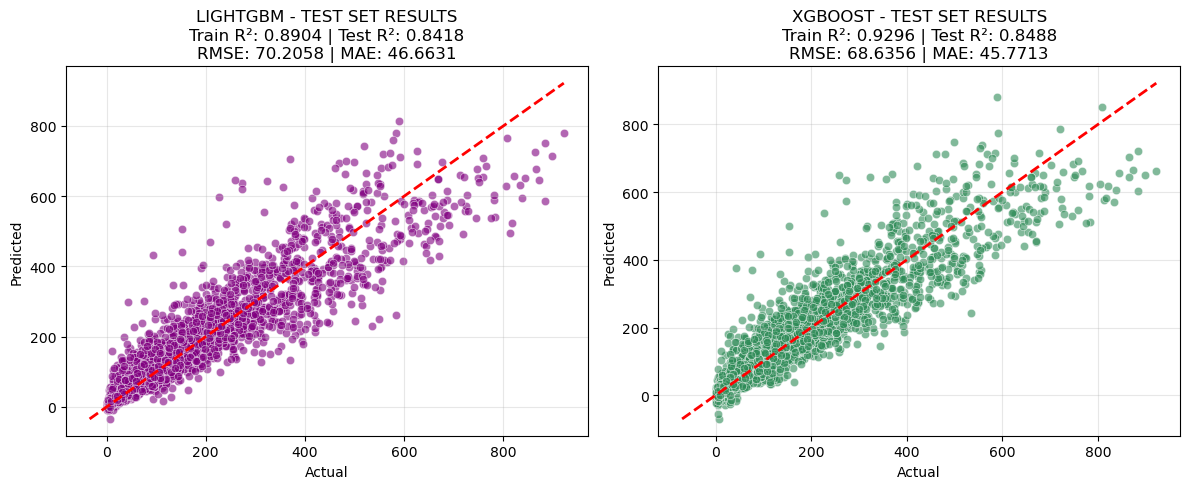

In [24]:
models = {
    'lightgbm': LGBMRegressor(random_state=42, verbose=-1),
    'xgboost': XGBRegressor(random_state=42),
}


test_results = []
predictions = {}

for name, base_model in models.items():
    
    model = Pipeline([
        ('preprocessing', transformer),
        ('model', base_model)
    ])
    
    model.fit(X_train, y_train)
    
    # Predict untuk TRAIN dan TEST
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    predictions[name] = y_test_pred
    
    # Hitung metrics untuk TRAIN
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Hitung metrics untuk TEST
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    test_results.append({
        'Model': name,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_MAPE': train_mape,
        'Test_MAPE': test_mape,
        'Train_R2': train_r2,
        'Test_R2': test_r2
    })

score_before_tuning = pd.DataFrame(test_results)

print("Score Before Tuning (Train vs Test):")
display(score_before_tuning)


# Scatter Plot Comparison
color=['purple', 'seagreen']
plt.figure(figsize=(12,5))

for i, name in enumerate(models.keys()):
    
    df_plot = pd.DataFrame({
        'Actual': y_test,
        'Predicted': predictions[name]
    })
    
    plt.subplot(1, 2, i+1)
    sns.scatterplot(data=df_plot, x='Actual', y='Predicted', alpha=0.6, color=color[i])
    
    min_val = min(df_plot['Actual'].min(), df_plot['Predicted'].min())
    max_val = max(df_plot['Actual'].max(), df_plot['Predicted'].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    metrics = score_before_tuning[score_before_tuning['Model'] == name].iloc[0]
    
    plt.title(
        f"{name.upper()} - TEST SET RESULTS\n"
        f"Train R²: {metrics['Train_R2']:.4f} | Test R²: {metrics['Test_R2']:.4f}\n"
        f"RMSE: {metrics['Test_RMSE']:.4f} | MAE: {metrics['Test_MAE']:.4f}"
    )
    
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Before tuning, both *LightGBM* and *XGBoost* show strong performance, though a noticeable gap emerges between them. Based on cross-validation results, *LightGBM* performs slightly better on average, with marginally lower RMSE and MAE, and a slightly higher R². However, these differences are small and indicate that both models are comparably effective.

In the initial test evaluation, a clear performance difference appears. **XGBoost** achieves a **lower RMSE (68.64)** and a **higher R² (0.849)** compared to *LightGBM* (RMSE: 70.21, R²: 0.842). This difference indicates that XGBoost generalizes better to unseen data even before hyperparameter optimization. Interestingly, LightGBM shows a better MAPE (0.559 vs. 0.596), suggesting it may be more accurate in percentage-based terms, particularly for lower-demand periods.

The scatter plots further support these findings, with *XGBoost*'s predictions aligning more closely with the diagonal reference line, indicating more accurate and consistent predictions across the value range.

Overall, both models demonstrate solid baseline performance, but **XGBoost shows an early advantage in the initial test evaluation**, particularly in terms of absolute error metrics (RMSE, MAE) that are most relevant for predicting bike rental demand.


### **5. Hyperparameter Tuning (LightGBM and XGBoost)**

(Final Evaluation with Train-Test Comparison)

SCORE AFTER TUNING:


,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_MAPE,Test_MAPE,Train_R2,Test_R2,Best_Params
0,lightgbm,56.682985,68.400025,38.836200,45.435349,0.463287,0.533031,0.903355,0.849880,"{'model__subsample': 0.9, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0, 'model__num_leaves': 31, 'model__n_estimators': 400, 'model__min_child_samples': 20, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.9}"
1,xgboost,49.281396,67.849954,33.545124,45.212143,0.421773,0.548202,0.926946,0.852285,"{'model__subsample': 0.7, 'model__reg_lambda': 1, 'model__reg_alpha': 0, 'model__n_estimators': 300, 'model__max_depth': 7, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}"


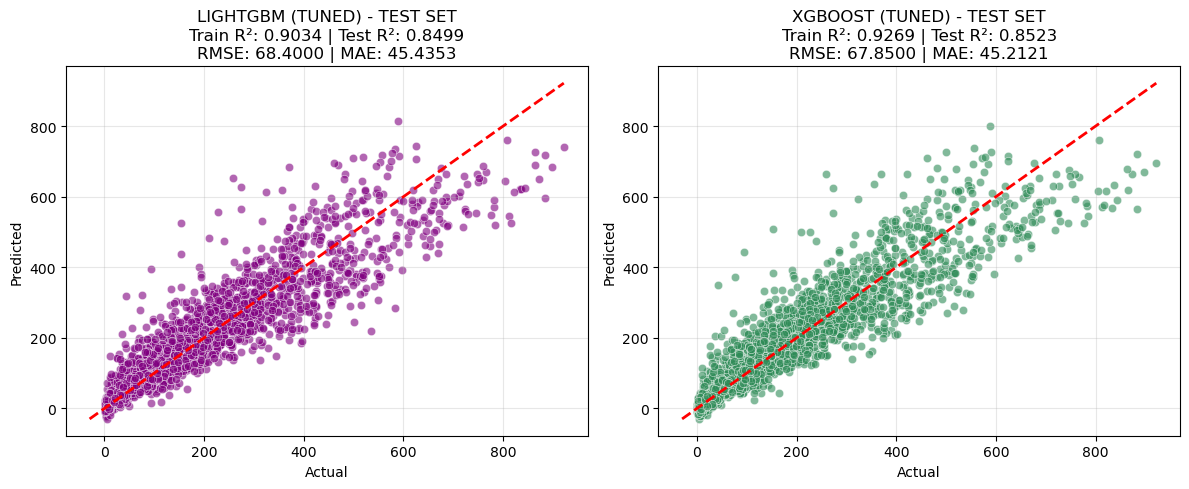

dict_keys(['lightgbm', 'xgboost'])


In [25]:
param_grid_lgbm = {
    'model__n_estimators': [200, 400, 600],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__num_leaves': [31, 63, 127],
    'model__max_depth': [-1, 5, 10],
    'model__min_child_samples': [20, 40, 60],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9],
    'model__reg_alpha': [0, 0.1, 0.5],
    'model__reg_lambda': [0.5, 1, 1.5]
}

param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9],
    'model__reg_alpha': [0, 0.1, 1],
    'model__reg_lambda': [1, 1.5, 2]
}

models_tuned = {
    'lightgbm': LGBMRegressor(random_state=42, verbose=-1),
    'xgboost': XGBRegressor(random_state=42)
}

param_grids = {
    'lightgbm': param_grid_lgbm,
    'xgboost': param_grid_xgb
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_estimators = {}

# Store results
tuning_results = []
y_pred_dict = {}

for name in models_tuned:
    # Pipeline
    pipeline = Pipeline([
        ('preprocessing', transformer),
        ('model', models_tuned[name])
    ])
    
    random_search = RandomizedSearchCV(
        pipeline,
        param_grids[name],
        n_iter=20,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        random_state=42
    )
    
    # Fit to training data
    random_search.fit(X_train, y_train)
    
    # Get best model
    best_model = random_search.best_estimator_
    
    best_estimators[name] = best_model

    # Predict for TRAIN and TEST
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    
    y_pred_dict[name] = y_test_pred
    
    # Calculate TRAIN metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Calculate TEST metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Store results
    tuning_results.append({
        'Model': name,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_MAPE': train_mape,
        'Test_MAPE': test_mape,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Best_Params': random_search.best_params_
    })

# Create DataFrame
score_after_tuning = pd.DataFrame(tuning_results)

print("SCORE AFTER TUNING:")
display(score_after_tuning)

# Scatter Plot for Tuned Models
plt.figure(figsize=(12,5))
colors = ['purple', 'seagreen']

for i, (name, color) in enumerate(zip(models_tuned.keys(), colors)):
    
    plt.subplot(1, 2, i+1)
    
    # Scatter plot
    sns.scatterplot(x=y_test, y=y_pred_dict[name], alpha=0.6, color=color)
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred_dict[name].min())
    max_val = max(y_test.max(), y_pred_dict[name].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    # Get metrics
    metrics = score_after_tuning[score_after_tuning['Model'] == name].iloc[0]
    
    plt.title(
        f"{name.upper()} (TUNED) - TEST SET\n"
        f"Train R²: {metrics['Train_R2']:.4f} | Test R²: {metrics['Test_R2']:.4f}\n"
        f"RMSE: {metrics['Test_RMSE']:.4f} | MAE: {metrics['Test_MAE']:.4f}"
    )
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SETELAH LOOP - baru bisa pake best_estimators
print(best_estimators.keys()) 

In [26]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

After tuning, both models show improved performance. **XGBoost** maintains a slight advantage with **lower RMSE (67.85 vs. 68.40)** and **MAE (45.21 vs. 45.44)** compared to *LightGBM*. However, *LightGBM* achieves a better MAPE (0.533 vs. 0.548), indicating more accurate percentage-based predictions for lower-demand periods. Both models show comparable R² scores (0.852 vs. 0.850).

The tuning process benefited both models, with *LightGBM* showing a more substantial RMSE improvement (1.81 points vs. 0.79 points for XGBoost), narrowing the performance gap between them. The RMSE difference shrank from 1.57 points pre-tuning to just 0.55 points post-tuning.

The scatter plots confirm *XGBoost*'s predictions align slightly closer to the diagonal, particularly at higher values, while LightGBM's better MAPE suggests strength in lower-demand periods.

Overall, **XGBoost remains the preferred model** for bike rental demand forecasting, as its superior absolute error metrics (RMSE, MAE) are most relevant for operational decisions. However, LightGBM offers a compelling alternative if percentage-based accuracy or faster training (5.37s vs. 0.39s) is prioritized.



**Residual Count**

(Best model : XGBoost)

In [27]:
display(score_before_tuning[
    score_before_tuning['Model']=='xgboost'
],
score_after_tuning[
    score_after_tuning['Model']=='xgboost'
])

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_MAPE,Test_MAPE,Train_R2,Test_R2
1,xgboost,48.361127,68.635569,32.667927,45.771328,0.445883,0.595988,0.929649,0.848844


,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_MAPE,Test_MAPE,Train_R2,Test_R2,Best_Params
1,xgboost,49.281396,67.849954,33.545124,45.212143,0.421773,0.548202,0.926946,0.852285,"{'model__subsample': 0.7, 'model__reg_lambda': 1, 'model__reg_alpha': 0, 'model__n_estimators': 300, 'model__max_depth': 7, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}"


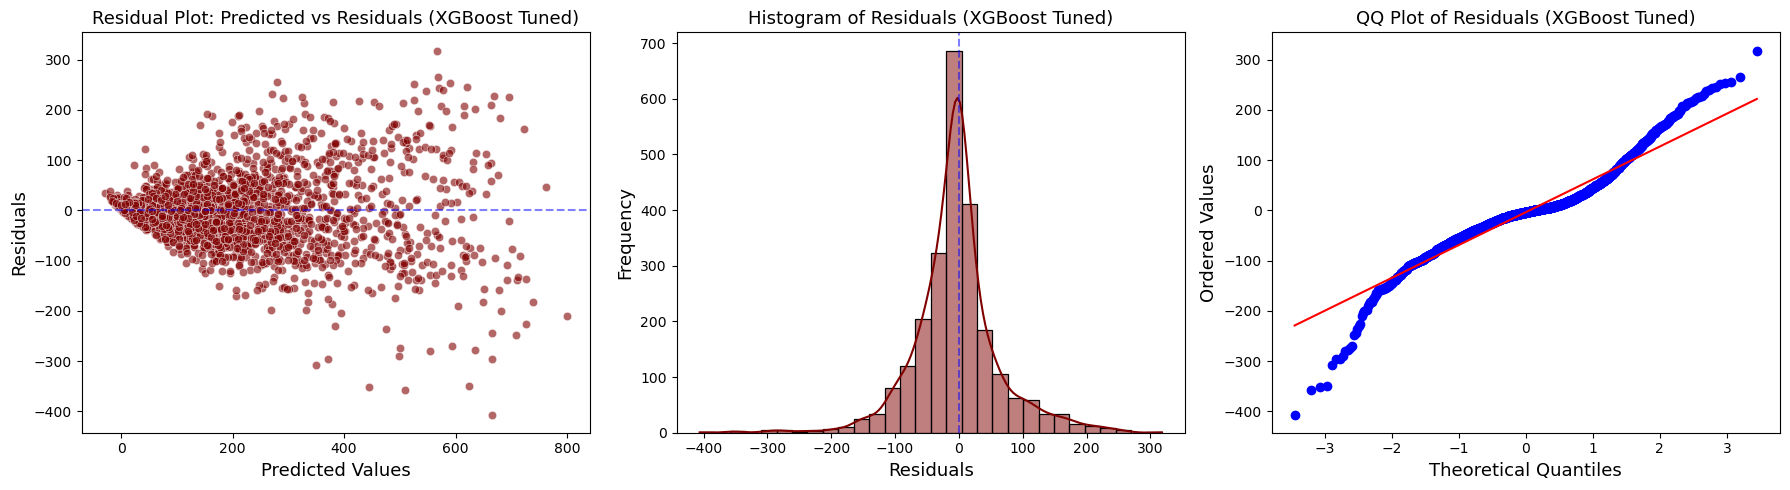

XGBoost Tuned - Error Direction Analysis
Total observations       : 2433
Underestimation count    : 1090 (Prediction < Actual)
Overestimation count     : 1343 (Prediction > Actual)
Exact prediction count   : 0 (Prediction = Actual)

------------------------------------------------------------
RATES:
Underestimation rate     : 44.80%
Overestimation rate      : 55.20%
Exact match rate         : 0.00%


In [28]:
# Residual Analysis
# get data from y_pred_dict['name']
df_xgb_tuned = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_dict['xgboost']
})

residuals = df_xgb_tuned['Actual'] - df_xgb_tuned['Predicted']

plt.figure(figsize=(18,5))

# Residual Plot
plt.subplot(1, 3, 1)
sns.scatterplot(x=df_xgb_tuned['Predicted'], y=residuals, color='maroon', alpha=0.6)
plt.axhline(y=0, color='b', linestyle='--', alpha=0.5)
plt.xlabel("Predicted Values", fontsize=13)
plt.ylabel("Residuals", fontsize=13)
plt.title("Residual Plot: Predicted vs Residuals (XGBoost Tuned)", fontsize=13)

# Histogram
plt.subplot(1, 3, 2)
sns.histplot(residuals, bins=30, kde=True, color='maroon')
plt.axvline(x=0, color='b', linestyle='--', alpha=0.5)
plt.xlabel("Residuals", fontsize=13)
plt.ylabel("Frequency", fontsize=13)
plt.title("Histogram of Residuals (XGBoost Tuned)", fontsize=13)

# QQ Plot
plt.subplot(1, 3, 3)
stats.probplot(residuals, dist="norm", plot=plt)
plt.xlabel('Theoretical Quantiles', fontsize=13)
plt.ylabel('Ordered Values', fontsize=13)
plt.title("QQ Plot of Residuals (XGBoost Tuned)", fontsize=13)

plt.tight_layout()
plt.show()

# Count Under / Over Estimation
underestimation_count = (df_xgb_tuned["Predicted"] < df_xgb_tuned["Actual"]).sum()
overestimation_count = (df_xgb_tuned["Predicted"] > df_xgb_tuned["Actual"]).sum()
exact_match_count = (df_xgb_tuned["Predicted"] == df_xgb_tuned["Actual"]).sum()

total_obs = len(df_xgb_tuned)

# Calculate Rates
underestimation_rate = underestimation_count / total_obs
overestimation_rate = overestimation_count / total_obs
exact_match_rate = exact_match_count / total_obs

# Print Results
print("XGBoost Tuned - Error Direction Analysis")
print(f"Total observations       : {total_obs}")
print(f"Underestimation count    : {underestimation_count} (Prediction < Actual)")
print(f"Overestimation count     : {overestimation_count} (Prediction > Actual)") 
print(f"Exact prediction count   : {exact_match_count} (Prediction = Actual)")

print("\n" + "-"*60)
print("RATES:")
print(f"Underestimation rate     : {underestimation_rate:.2%}")
print(f"Overestimation rate      : {overestimation_rate:.2%}")
print(f"Exact match rate         : {exact_match_rate:.2%}")

From the residual plot, the residuals are mostly centered around zero, **though with a slight overestimation tendency** (55.20% overestimations vs. 44.80% underestimations). This near-balance indicates reasonably fair predictive behavior despite the mild bias. However, the spread of residuals becomes slightly wider as predicted values increase, pointing to mild heteroscedasticity (non-constant variance). A few large negative residuals are also visible, meaning the model sometimes substantially underpredicts demand during certain high-demand periods.

The histogram of residuals further shows that most prediction errors cluster around zero, which reflects good overall accuracy. That said, the distribution is not perfectly symmetrical and appears to have heavier tails, especially on the negative side. This pattern suggests the presence of outliers or more extreme prediction errors in certain cases.

The QQ plot reinforces this observation. While the residuals align fairly well with the reference line in the middle range, noticeable deviations appear at both ends, particularly in the lower tail. This indicates that the residuals do not follow a perfectly normal distribution and tend to exhibit heavier tails than expected.

Overall, the XGBoost model performs reliably, with residuals generally centered around zero and a reasonably balanced proportion of under- and overestimations. Although there is some mild heteroscedasticity, a slight overestimation tendency (55.20%), and a few extreme errors, the model captures overall demand patterns effectively. Its main limitation appears when predicting unusually high-demand periods, where errors become more pronounced.

The residual plot reveals that most prediction errors are scattered around zero. There is a **slight overestimation tendency**, with 55.20% of predictions exceeding actual values compared to 44.80% underestimations. This near-balanced distribution suggests that the model's predictive behavior is reasonably fair, despite the mild bias.

Looking closer at the pattern, the spread of residuals tends to widen as predicted values increase. This indicates **mild heteroscedasticity**. Meaning, the model's prediction errors become more variable when demand is higher. A few large negative residuals are also visible, signaling that the model occasionally **underpredicts demand during peak periods**. From a business perspective, these underestimation cases (44.80%) could potentially lead to bike shortages. A situation that may cause customer dissatisfaction.

The histogram of residuals supports this view. Most errors cluster neatly around zero, reflecting solid overall accuracy. That said, the distribution isn't perfectly symmetrical; it shows **heavier tails**, particularly on the negative (underestimation) side. This confirms the presence of outliers or more extreme prediction errors in certain high-demand scenarios.

The QQ plot reinforces the same story. While the residuals follow the reference line fairly well in the middle range, they start to deviate at both ends—especially in the lower tail. This tells us the residuals aren't perfectly normally distributed and tend to have more extreme values than a perfect model would produce.



**Connecting Back to Business Impact**

This pattern aligns directly with the two core business challenges:

| Error Type | Percentage | Business Impact |
|------------|------------|-----------------|
| **Overestimation** (Prediction > Actual) | 55.20% | Excess idle bikes → wasted maintenance costs, inefficiency |
| **Underestimation** (Prediction < Actual) | 44.80% | Bike shortages → customer dissatisfaction, lost revenue |

Interestingly, the model shows a **slightly higher tendency to overestimate** (55.20%) than underestimate. This means the system is more likely to prepare too many bikes than too few—a conservative approach that prioritizes availability over efficiency. While this helps avoid customer disappointment (problem #1), it may contribute to operational inefficiencies and higher maintenance costs (problem #2).



**Conclusion**

Overall, the XGBoost model performs reliably. It captures general demand patterns well, with residuals centered near zero and a reasonably balanced error direction. However, the model's main limitation emerges when predicting **unusually high-demand periods**, where errors become more pronounced. *For business stakeholders, this means the system can be trusted for day-to-day operations, but should be used with caution—or supplemented with additional rules—during peak seasons or special events where demand spikes unexpectedly.*

### **6. Feature Importance**

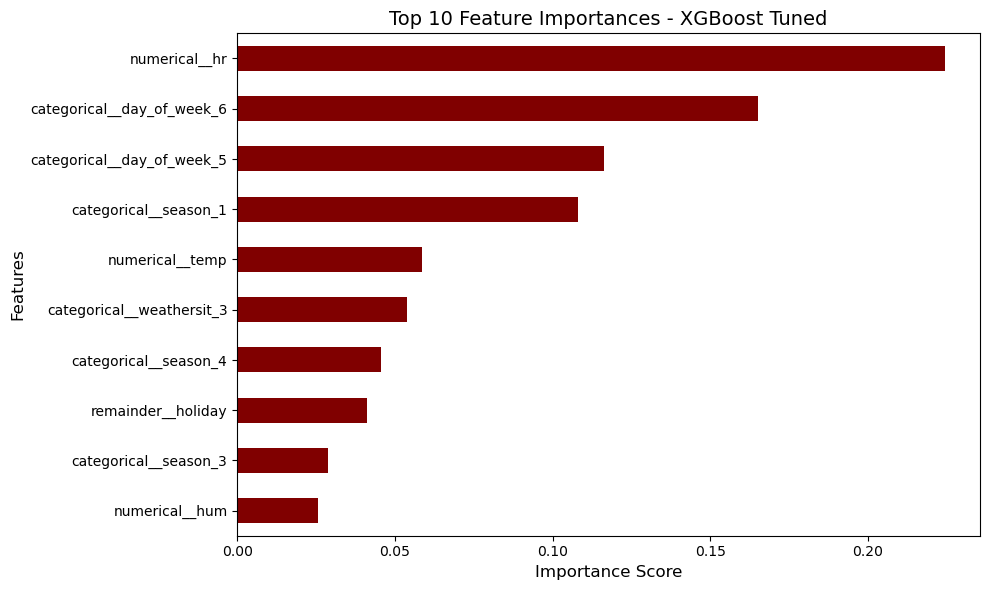


Top 10 Feature Importances - XGBoost Tuned:


,Importance
numerical__hr,0.224338
categorical__day_of_week_6,0.165175
categorical__day_of_week_5,0.116244
categorical__season_1,0.107959
numerical__temp,0.058608
categorical__weathersit_3,0.053972
categorical__season_4,0.045701
remainder__holiday,0.041027
categorical__season_3,0.028915
numerical__hum,0.025503


In [29]:
# Get feature names from transformer
feature_names = transformer.get_feature_names_out()

# Get feature importance from XGBoost model in pipeline
xgb_model = best_model.named_steps['model']

xgb_feature_imp = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Top 10 features
plt.figure(figsize=(10,6))
xgb_feature_imp.head(10).plot(kind='barh', color='maroon')
plt.title('Top 10 Feature Importances - XGBoost Tuned', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Tampilkan dalam dataframe
print("\nTop 10 Feature Importances - XGBoost Tuned:")
display(xgb_feature_imp.head(10).to_frame('Importance'))

ExactExplainer explainer: 2001it [02:14, 14.72it/s]                          


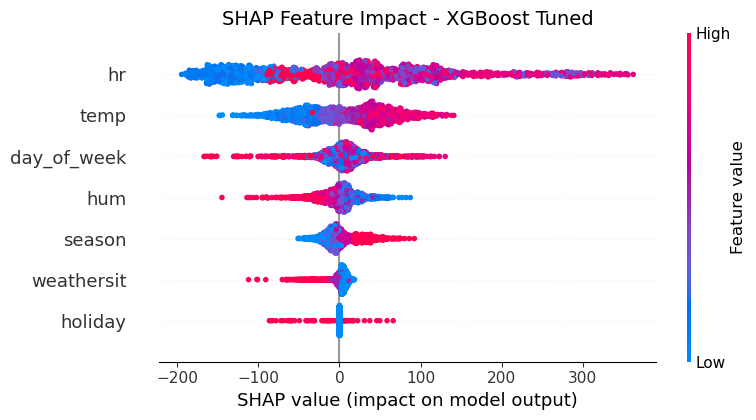

In [30]:
# Sampling 2000 dari X_test
X_sample = X_test.sample(2000, random_state=42)

# Define explainer - pake best_model (yang sudah XGBoost)
explainer = shap.Explainer(best_model.predict, X_sample)

# Calculate shap values
shap_values = explainer(X_sample)

# Beeswarm plot
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, show=False)
plt.title('SHAP Feature Impact - XGBoost Tuned', fontsize=14)
plt.tight_layout()
plt.show()

Notes: 

- Red SHAP values represent higher feature values.
- Blue SHAP values represent lower feature values.
- The SHAP value axis indicates whether a feature increases or decreases the predicted demand.

The SHAP plot shows how each feature contributes to the *XGBoost* model's predictions and ranks them by overall importance.

The most influential feature is **hour** (`hr`), which shows the widest spread of SHAP values, indicating the strongest impact on the model output. Higher hour values (shown in red) generally push predictions upward, while lower hour values (blue) tend to reduce the predicted value. This confirms that bike rental demand follows clear intraday patterns, with peak hours driving higher predictions.

The second most important feature is **temperature** (`temp`), which exhibits a strong positive relationship: higher temperatures (red) consistently increase predicted demand, while lower temperatures (blue) decrease it. This aligns with expectations that people are more likely to rent bikes in warmer conditions.

**Day of week** (`day_of_week`) follows as the third most influential feature, with its effects varying across categories—certain days increase demand while others decrease it, reflecting differences between weekday and weekend usage patterns.

**Humidity** (`hum`) shows moderate influence, with higher humidity values (red) generally decreasing predicted demand—suggesting that less comfortable, more humid conditions discourage bike rentals. Lower humidity values (blue) tend to increase predictions.

**Season** (`season`) and **weather situation** (`weathersit`) exhibit smaller but still noticeable effects. Different seasons shift predictions up or down depending on the specific season, while better weather conditions (lower weathersit values) generally increase predicted demand.

**Holiday** (`holiday`) has the least impact overall, with most SHAP values clustered near zero, suggesting it plays a relatively minor role in the model's predictions—likely because `holiday` effects are already partially captured by day of week and hour patterns.

Overall, the model relies most heavily on **temporal patterns (hour and day of week)** and **weather conditions (temperature and humidity)**, while `holiday` effects appear comparatively limited in driving bike rental demand predictions.

**Actionable Recommendation on Business Impact:**

- Boost bike supply during peak hours (8:00–9:00 AM) to meet high demand from morning commuters.

- Add more bikes on warm days and reduce fleet size in cold weather, as temperature strongly influences rentals.

- Scale back operations during humid conditions, since high humidity discourages ridership and reduces demand.

### **7. Cost-Benefit Analysis**

Revisiting the operational risks, two main problems stand out: 

1) **Bike shortages during peak demand**, which can result in lost revenue and lower customer satisfaction (cost of underestimation) → Assuming a cost of $4 per bike

2) **Excess idle bikes during low-demand periods**, which increase redistribution and maintenance costs (cost of overestimation) → Assuming a cost of $1.50 per bike

Using the tuned XGBoost model, the evaluation results show **RMSE = 67.85**, **MAE = 45.21**, and **MAPE = 54.82%**. From a business perspective, MAE is the most practical metric because it represents the average hourly gap between predicted and actual demand. An MAE of 45.21 means that, **on average, the forecast differs by about 45 bikes per recorded hour**.

Based on publicly available pricing from Capital Bikeshare, a typical ride costs $1 to unlock plus $0.15 per minute. Assuming an average trip duration of 15 minutes, **the estimated revenue per ride is $3.25**. This implies that an average deviation of 45 bikes corresponds to a **potential revenue exposure of 45 × $3.25 = $146.25 per hour**. If extended to 24 operational hours, this equals about **$3,510 per day**, or approximately **$105,300 per month** (assuming 30 days).

However, this simple multiplication assumes every error has equal financial impact—which is not the case. To better reflect actual financial impact, prediction errors should be adjusted based on their economic consequences. The model's error distribution consists of **44.80% underestimations** and **55.20% overestimations**. Using the asymmetric cost structure ($4 per bike for underestimation vs. $1.50 per bike for overestimation), the expected hourly loss under the XGBoost model can be estimated as follows:

- **Underestimation cost** = 44.80% × 45 × $4 = 0.4480 × 45 × $4 ≈ **$80.64**

- **Overestimation cost** = 55.20% × 45 × $1.50 = 0.5520 × 45 × $1.50 ≈ **$37.26**

Together, this results in an expected loss of approximately **$117.90 per hour**. Over a full day, this amounts to about **$2,830 per day**, or roughly **$84,900 per month**.

For comparison, a baseline scenario without machine learning can be considered. In hourly demand forecasting contexts similar to this dataset, simple non-ML baseline methods (such as historical averages or naive seasonal forecasts) typically yield MAE values in the range of 55–65 bikes per hour. Therefore, assuming a conservative baseline MAE of **60 bikes per hour** provides a reasonable reference point for economic comparison. Using the same cost assumptions and error proportions, the expected hourly loss under this baseline would be:

- **Underestimation cost** = 44.80% × 60 × $4 = 0.4480 × 60 × $4 ≈ **$107.52**

- **Overestimation cost** = 55.20% × 60 × $1.50 = 0.5520 × 60 × $1.50 ≈ **$49.68**

This results in a total expected loss of approximately **$157.20 per hour**, or about **$3,773 per day** and **$113,190 per month**.

In practical terms, adopting the XGBoost model reduces expected monthly operational losses from approximately $113,190 to $84,900, generating an estimated monthly savings of around **$28,290**. On an annual basis, this represents potential savings of approximately **$339,480**.

It is worth noting that this analysis uses conservative assumptions. The actual financial benefit could be even higher when considering:
- **Peak hour prioritization**: The model's slight overestimation tendency (55.20%) is actually favorable, as overestimation costs ($1.50/bike) are substantially lower than underestimation costs ($4/bike)
- **Compound effects**: Improved customer satisfaction during peak hours can drive long-term loyalty and ridership
- **Operational efficiency**: More accurate predictions reduce unnecessary bike redistribution trips, lowering fuel and labor costs

Overall, although the model is not perfect, it delivers clear financial value by improving demand forecasting accuracy and reducing operational inefficiencies compared to a non-ML forecasting approach. The **~$339,000 in estimated annual savings** provides a strong business case for deploying the XGBoost model in production.

**Cost Assumptions**

| Error Type | Cost per Bike | Proportion |
|------------|--------------|------------|
| Underestimation | $4.00 | 44.80% |
| Overestimation | $1.50 | 55.20% |

**Pricing Assumptions**

| Component | Value |
|------------|--------|
| Unlock fee | $1.00 |
| Per-minute rate | $0.15 |
| Average trip duration | 15 minutes |
| Estimated revenue per ride | $3.25 |

**Economic Impact Comparison: With ML vs Without ML**

| Metric | XGBoost Model (With ML) | Baseline (Without ML, MAE = 60) |
|--------|--------------------------|----------------------------------|
| MAE (bikes/hour) | 45 | 60 |
| Underestimation proportion | 44.80% | 44.80% |
| Overestimation proportion | 55.20% | 55.20% |
| Revenue exposure per hour | $146.25 | — |
| **Hourly Cost Breakdown** | | |
| Underestimation cost per hour | $80.64 | $107.52 |
| Overestimation cost per hour | $37.26 | $49.68 |
| **Total expected hourly loss** | **$117.90** | **$157.20** |
| **Aggregated Losses** | | |
| Expected daily loss (×24) | $2,830 | $3,773 |
| Expected monthly loss (30 days) | $84,900 | $113,190 |
| Expected annual loss | $1,018,800 | $1,358,280 |
| **Savings from ML** | | |
| Monthly savings | **$28,290** | — |
| Annual savings | **$339,480** | — |

*Notes:* 

*- Calculations assume $4 cost per bike for underestimation errors and $1.50 cost per bike for overestimation errors.*

*- Underestimation cost = underestimation proportion × MAE × $4;*

*- Overestimation cost = overestimation proportion × MAE × $1.50.* 

*- Revenue exposure (MAE × $3.25) represents the gross revenue value of all mispredicted bikes.* 

*- MAE values have been rounded to the nearest whole number for practical business interpretation.*

### **8. Model Limitation**

| Column            | Definition                                              |
| ----------------- | ------------------------------------------------------- |
| Hour              | Hour of the day (0–23).                                 |
| Temperature       | Actual air temperature, normalized to the range [0, 1]. |
| Day of Week       | Day of the week (0 = Monday, ..., 6 = Sunday).          |
| Humidity          | Relative humidity, normalized to the range [0, 1].      |
| Season            | Season category (1, 2, 3, 4).                           |
| Weather Situation | Weather situation category (1, 2, 3, 4).                |
| Holiday           | Holiday indicator (1 = holiday, 0 = not holiday).       |

The model is limited to the features available in the dataset: temporal indicators (hour, day of week), weather-related variables (temperature, humidity, weather situation), and calendar indicators (season and holiday). Since the data covers only 2011–2012, the model does not capture long-term structural trends. Additionally, the absence of socio-economic, policy, and event-related variables may reduce predictive robustness. Weather conditions are represented in simplified and normalized forms, which may limit interpretability. Therefore, model predictions should be interpreted within the scope of the available features and time horizon.


### **9. Conclusion**

#### 9.1. Summary of Modeling Approach

Capital Bikeshare currently operates more than 8,000 bicycles across over 800 stations, which creates a complex operational challenge that requires an accurate bike rental demand prediction. We developed a predictive model for bike rental demand using the **XGBoost algorithm**, selected after benchmarking multiple machine learning models. Hyperparameter tuning was performed using randomized search with cross-validation to optimize model performance. The final model was evaluated on key regression metrics (RMSE, MAE, MAPE, R²) and analyzed using SHAP for interpretability, residual diagnostics, and error direction analysis to understand prediction patterns and business implications.

#### 9.2. Model Performance Summary
The tuned XGBoost model achieved the following performance on the test set:
- **RMSE**: 67.85
- **MAE**: 45.21 (rounded to **45 bikes per hour** for practical interpretation)
- **MAPE**: 54.82%
- **R²**: 0.852

The model explains approximately **85.2% of the variance** in hourly bike rental demand. Error direction analysis shows a reasonably balanced prediction pattern with **44.80% underestimations** and **55.20% overestimations**, indicating no severe systematic bias. Residual diagnostics confirm that most errors cluster around zero, though the model shows mild heteroscedasticity and performs best in mid-range demand periods, with some limitations during extreme high-demand hours.

Feature importance analysis using SHAP reveals that **hour of the day** is the most influential predictor, followed by **temperature** and **day of week**, confirming that rental demand is primarily driven by time-based patterns and weather conditions.

#### 9.3. Business Impact and Cost-Benefit Analysis
From an operational perspective, MAE is the most practical metric, representing the average hourly gap between predicted and actual demand. With an MAE of **45 bikes per hour**, the model's predictions deviate by approximately 45 bikes each hour. Using a conservative cost structure: **$4 per bike for underestimation** (lost revenue and customer dissatisfaction) and **$1.50 per bike for overestimation** (redistribution and maintenance costs), the expected financial impact is as follows:

| Metric | XGBoost Model | Baseline (MAE = 60) |
|--------|---------------|---------------------|
| Total expected hourly loss | **$117.90** | $157.20 |
| Expected monthly loss | **$84,900** | $113,190 |
| **Monthly savings from ML** | **$28,290** | — |
| **Annual savings from ML** | **$339,480** | — |

Compared to a non-ML baseline approach (with an estimated MAE of 60 bikes per hour), deploying the XGBoost model is projected to deliver **approximately $340,000 in annual savings**, primarily driven by improved demand precdicting accuracy that reduces both lost revenue from bike shortages and unnecessary operational costs from excess idle bikes.

#### 9.4. Recommendations

Based on the data analysis, implementing the XGBoost model for demand prediction is recommended. Additionally, the following operational areas require special attention to optimize resource allocation and maximize revenue.

**1. Dynamic Bike Inventory Management Based on Commuter Patterns**

The data indicates that bike rentals are primarily driven by commuting rather than leisure. Therefore, bike distribution must be dynamically adjusted to accommodate predictable rush hour flows.

- **Focus Areas:** Concentrate bike distribution around high-traffic areas such as office districts, business parks, and schools during peak times.
- **Peak Hour Strategy:** Prioritize bike availability during the identified rush hour windows to meet commuter demand and prevent shortages.

| Time Period | Demand Category | Operational Implication |
| :--- | :--- | :--- |
| 07:00 – 09:00 | **Rush Hour** | Ensure maximum bike availability at commuter hubs. |
| 08:00 | **Peak Rush Hour** | Highest priority for bike readiness and staffing. |
| 10:00 | Off-Peak | Opportunity for redistribution and light maintenance. |
| 11:00 – 12:00 | Crowded (Lunch Break) | Moderate demand; monitor for short-distance trips. |
| 13:00 – 15:00 | Off-Peak | Ideal window for bike redistribution between stations. |
| 15:00 – 17:00 | **Evening Rush Hour** | Second peak; ensure bikes are available for the return commute. |
| 18:00 – 23:00 | Off-Peak | Low demand; suitable for fleet maintenance and charging. |

**2. Proactive Planning Based on Demand Thresholds**

To optimize redistribution and maintenance planning, it is crucial to use the model's output as a guide. Operational protocols should be triggered based on the predicted demand level for a given time period, rather than on real-time or historical counts. The following thresholds, derived from historical data analysis, can be used to interpret the model's predictions and guide resource allocation.

- **Resource Allocation:** Use the demand thresholds to trigger specific operational protocols.
- **Predictive Redistribution:** When a "Very High Demand" day is forecasted, proactively deploy additional staff and redistribution vehicles to busier areas.

| Demand Level | Hourly Rental Count | Operational Response |
| :--- | :--- | :--- |
| **Low Demand** | ≤ 40 | Minimal redistribution; focus on scheduled maintenance. |
| **Moderate Demand** | 41 – 282 | Standard operations; monitor for shifts toward "High Demand". |
| **High Demand** | 283 – 645 | Increase redistribution frequency; prepare for surge. |
| **Very High Demand** | > 645 | Activate surge protocols; deploy all available fleet and staff. |

**3. Targeted Marketing and Retention Strategies**

Understanding the distinct behaviors of casual and registered users allows for more effective marketing campaigns.

- **Focus on Registered Users (Retention):** Since registered users are the backbone of daily demand, offer loyalty programs or annual subscription discounts, especially during the transition from fall to winter. This strategy aims to retain a stable user base throughout the lower-demand seasons.
- **Focus on Casual Users (Acquisition):** Launch targeted marketing campaigns during the summer and early fall when overall demand is high. Promote weekend rental packages or discounts for popular tourist routes to convert casual users into more frequent riders.



#### 9.5. Overall Conclusion

This project set out to address a critical operational challenge for Capital Bikeshare: predicting hourly rental demand to optimize the deployment of over 8,000 bicycles across 800 stations. By leveraging machine learning, the aim is to move from a reactive operational model to a proactive, data-driven strategy that minimizes both bike shortages and costly idle inventory.

The final **XGBoost model** achieved this goal, demonstrating strong predictive power by explaining **85.2% of the variance in hourly demand (R² = 0.852)**. With a Mean Absolute Error of **45 bikes per hour**, the model provides a reliable and practical tool for daily decision-making.

The business impact of this accuracy is substantial. By improving forecast precision, the model is projected to generate an estimated **$340,000 in annual savings**. These savings are achieved by simultaneously reducing two key inefficiencies: the lost revenue and customer dissatisfaction caused by bike shortages, and the unnecessary operational costs associated with redistributing and maintaining excess idle bikes.

Beyond the financial benefits, the analysis yielded critical operational insights. Feature importance analysis confirmed that time-based patterns (hour of day, day of week) and weather (temperature) are the primary drivers of demand. This understanding directly informed a set of actionable strategies, including dynamic bike inventory management for rush hours, proactive planning based on predicted demand thresholds, and targeted marketing campaigns for both casual and registered users.

While the model performs robustly across most mid-range demand periods, it has limitations in predicting extreme spikes. To address this, a strategy of continuous monitoring and periodic retraining is recommended to ensure the model adapts to evolving demand patterns. In summary, the developed model provides a robust, interpretable, and business-ready foundation for transforming operational efficiency and significantly enhancing customer satisfaction.

**Save Model**

In [31]:
# XGBoost fit to all data
best_model = best_estimators['xgboost'].fit(X, y)

# Category of the number of demand
Q1 = float(y.quantile(0.25))
Q2 = float(y.quantile(0.50))
Q3 = float(y.quantile(0.75))
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

artifact = {
    "model": best_model,
    "low_threshold": Q1,
    "high_threshold": Q3,
    "upper_bound" : upper_bound
}

# Save model
with open("XGB_Tuned.sav", "wb") as f:
    pickle.dump(artifact, f)

print("✅ Models saved successfully!")

✅ Models saved successfully!
